In [1]:
# Install required packages
%pip install -q transformers datasets scikit-learn rouge-score evaluate nltk

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


### GPU Check

In [2]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


### Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Upload Dataset

In [4]:
import shutil

drive_csv_path = "/content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/Dataset/nav_dataset_b4.3.csv"
shutil.copy(drive_csv_path, "nav_dataset.csv")
print("Dataset ready!")


Dataset ready!


### Load and Split Dataset

In [5]:
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split

df = pd.read_csv("nav_dataset.csv")

# Remove exact duplicates based on both input and target
before_rows = len(df)
df = df.drop_duplicates(subset=["input", "target"]).reset_index(drop=True)
after_rows = len(df)

print("Data cleanup summary")
print(f"Rows before cleanup: {before_rows}")
print(f"Duplicate rows removed: {before_rows - after_rows}")
print(f"Rows remaining: {after_rows}")

# Extract action type for stratification
df['action_type'] = df['input'].str.extract(r'action: (\w+)')

print("\nAction type distribution (full dataset):")
print(df['action_type'].value_counts().to_string())

# Stratified 80/10/10 split.
# stratify=action_type ensures every action type keeps its proportion across
# train / val / test — prevents a split from being over-represented in one action.
train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['action_type']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['action_type']
)

print("\nAction type distribution per split:")
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    counts = split['action_type'].value_counts()
    print(f"  {name} ({len(split)}): {counts.to_dict()}")

# Drop helper column before building HuggingFace datasets
train_df = train_df.drop(columns=['action_type']).reset_index(drop=True)
val_df   = val_df.drop(columns=['action_type']).reset_index(drop=True)
test_df  = test_df.drop(columns=['action_type']).reset_index(drop=True)

train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)

print(f"\nTraining examples:   {len(train_dataset)}")
print(f"Validation examples: {len(val_dataset)}")
print(f"Test examples:       {len(test_dataset)}")


Data cleanup summary
Rows before cleanup: 3300
Duplicate rows removed: 1010
Rows remaining: 2290

Action type distribution (full dataset):
action_type
continue    702
exit        529
turn        424
stop        365
board       270

Action type distribution per split:
  Train (1832): {'continue': 562, 'exit': 423, 'turn': 339, 'stop': 292, 'board': 216}
  Val (229): {'continue': 70, 'exit': 53, 'turn': 43, 'stop': 36, 'board': 27}
  Test (229): {'continue': 70, 'exit': 53, 'turn': 42, 'stop': 37, 'board': 27}

Training examples:   1832
Validation examples: 229
Test examples:       229


### Tokenize Data

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("t5-small")

def preprocess(examples):
    model_inputs = tokenizer(
        ["navigate: " + x for x in examples["input"]],
        max_length=128,
        truncation=True,
    )
    labels = tokenizer(
        text_target=examples["target"],
        max_length=64,
        truncation=True,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(preprocess, batched=True, remove_columns=train_dataset.column_names)
tokenized_val = val_dataset.map(preprocess, batched=True, remove_columns=val_dataset.column_names)
tokenized_test = test_dataset.map(preprocess, batched=True, remove_columns=test_dataset.column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1832 [00:00<?, ? examples/s]

Map:   0%|          | 0/229 [00:00<?, ? examples/s]

Map:   0%|          | 0/229 [00:00<?, ? examples/s]

### Model Loading and Configuration

In [7]:
from transformers import (
    T5ForConditionalGeneration,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    )

model_output_dir = "/content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1"
base_model_name = "t5-small"

training_config = {
    "output_dir": "./nav_t5_model_v1",
    "num_train_epochs": 15,
    "per_device_train_batch_size": 32,
    "per_device_eval_batch_size": 32,
    "warmup_steps": 100,
    "weight_decay": 0.01,
    "logging_dir": "./logs",
    "logging_steps": 10,
    "eval_strategy": "epoch",
    "save_strategy": "epoch",
    "load_best_model_at_end": True,
    "fp16": True,
    "remove_unused_columns": False,
    "report_to": "none",
    "lr_scheduler_type": "cosine",
    "learning_rate": 3e-4,
    }

model = T5ForConditionalGeneration.from_pretrained(base_model_name)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)
training_args = TrainingArguments(**training_config)

run_artifacts = {
    "model_configuration": {
        "base_model": base_model_name,
        "tokenizer": base_model_name,
        "training_arguments": training_config,
        "early_stopping": {"patience": 3},
        "dataset_sizes": {
            "train": len(tokenized_train),
            "validation": len(tokenized_val),
            "test": len(tokenized_test),
            },
        },
    "epoch_losses": [],
    "training_summary": {},
    "curve_points": [],
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### Train the model

In [8]:
import json
import os
import pandas as pd

train_result = trainer.train()
print(train_result.metrics)

log_df = pd.DataFrame(trainer.state.log_history)

train_epoch_df = (
    log_df.dropna(subset=["epoch", "loss"])
.groupby("epoch", as_index=False)["loss"]
    .last()
    .rename(columns={"loss": "training_loss"})
)

val_epoch_df = (
    log_df.dropna(subset=["epoch", "eval_loss"])
.groupby("epoch", as_index=False)["eval_loss"]
    .last()
    .rename(columns={"eval_loss": "validation_loss"})
)

epoch_results_df = train_epoch_df.merge(val_epoch_df, on="epoch", how="outer").sort_values("epoch")
epoch_results_df["epoch"] = epoch_results_df["epoch"].round().astype("Int64")

output_dir = model_output_dir if "model_output_dir" in globals() else "./nav_t5_model_v1"
os.makedirs(output_dir, exist_ok=True)
artifact_path = os.path.join(output_dir, "training_artifacts.json")

if "run_artifacts" not in globals():
    run_artifacts = {
        "model_configuration": {},
        "epoch_losses": [],
        "training_summary": {},
        "curve_points": [],
        }

run_artifacts["epoch_losses"] = epoch_results_df.where(pd.notnull(epoch_results_df), None).to_dict(orient="records")
run_artifacts["training_summary"] = train_result.metrics

with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(run_artifacts, f, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o))

print(f"Saved artifacts to: {artifact_path}")

Epoch,Training Loss,Validation Loss
1,1.700685,0.986464
2,0.755251,0.689636
3,0.627676,0.605495
4,0.533780,0.582528
5,0.507279,0.568710
6,0.500939,0.556092
7,0.426372,0.534663
8,0.453656,0.530890
9,0.435972,0.532272
10,0.434250,0.537428


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


{'train_runtime': 181.4894, 'train_samples_per_second': 151.414, 'train_steps_per_second': 4.794, 'total_flos': 101548645416960.0, 'train_loss': 0.7415159697816663, 'epoch': 11.0}
Saved artifacts to: /content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1/training_artifacts.json


### Training Curves (Overfit / Underfit Check)
Plot training and validation loss from trainer logs to inspect model fit quality.

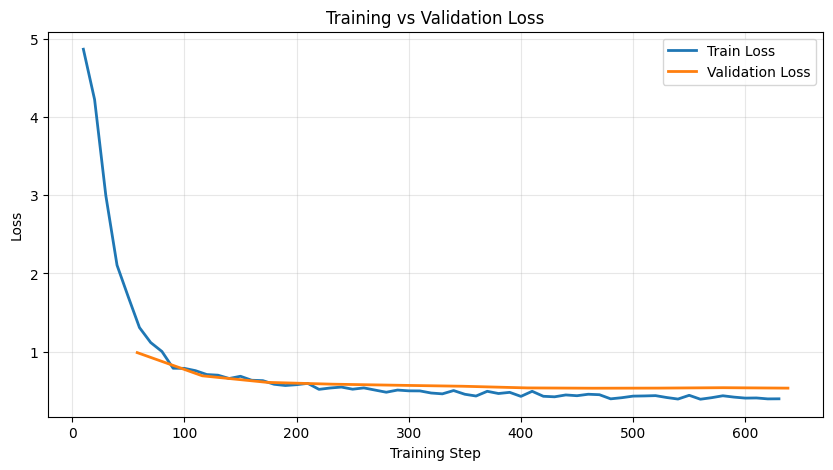

Latest train loss: 0.3953
Latest val loss:   0.5320
Generalization gap (val - train): 0.1366
Saved curve image to: /content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1/training_validation_loss.png
Updated artifacts file: /content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1/training_artifacts.json
Fit looks reasonable so far; confirm with held-out test metrics.


In [9]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

log_df = pd.DataFrame(trainer.state.log_history)
train_loss_df = log_df.dropna(subset=["loss"])[["step", "epoch", "loss"]].copy()
eval_loss_df = log_df.dropna(subset=["eval_loss"])[["step", "epoch", "eval_loss"]].copy()

if train_loss_df.empty or eval_loss_df.empty:
    print("Not enough log data to plot train/eval losses.")
else:
    plt.figure(figsize=(10, 5))
    plt.plot(train_loss_df["step"], train_loss_df["loss"], label="Train Loss", linewidth=2)
    plt.plot(eval_loss_df["step"], eval_loss_df["eval_loss"], label="Validation Loss", linewidth=2)
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    output_dir = model_output_dir if "model_output_dir" in globals() else "./nav_t5_model_v1"
    os.makedirs(output_dir, exist_ok=True)

    curve_image_path = os.path.join(output_dir, "training_validation_loss.png")
    plt.savefig(curve_image_path, dpi=200, bbox_inches="tight")
    plt.show()

    train_curve_df = train_loss_df.rename(columns={"loss": "train_loss"})[["step", "train_loss"]]
    eval_curve_df = eval_loss_df.rename(columns={"eval_loss": "validation_loss"})[["step", "validation_loss"]]
    merged_curve_df = pd.merge(train_curve_df, eval_curve_df, on="step", how="outer").sort_values("step")

    artifact_path = os.path.join(output_dir, "training_artifacts.json")
    if "run_artifacts" not in globals():
        run_artifacts = {
            "model_configuration": {},
            "epoch_losses": [],
            "training_summary": {},
            "curve_points": [],
            }
    run_artifacts["curve_points"] = merged_curve_df.where(pd.notnull(merged_curve_df), None).to_dict(orient="records")

    with open(artifact_path, "w", encoding="utf-8") as f:
        json.dump(run_artifacts, f, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o))

    latest_train_loss = float(train_loss_df.iloc[-1]["loss"])
    latest_val_loss = float(eval_loss_df.iloc[-1]["eval_loss"])
    loss_gap = latest_val_loss - latest_train_loss

    print(f"Latest train loss: {latest_train_loss:.4f}")
    print(f"Latest val loss:   {latest_val_loss:.4f}")
    print(f"Generalization gap (val - train): {loss_gap:.4f}")
    print(f"Saved curve image to: {curve_image_path}")
    print(f"Updated artifacts file: {artifact_path}")

    if loss_gap > 0.5:
        print("Potential overfitting signal: validation loss is much higher than training loss.")
    elif latest_train_loss > 1.5 and latest_val_loss > 1.5:
        print("Potential underfitting signal: both losses are still relatively high.")
    else:
        print("Fit looks reasonable so far; confirm with held-out test metrics.")

### Save Model

In [10]:
import os

save_path = model_output_dir if "model_output_dir" in globals() else "/content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1"
os.makedirs(save_path, exist_ok=True)

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model saved to {save_path}")
print("Artifacts in same folder: training_artifacts.json and training_validation_loss.png")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1
Artifacts in same folder: training_artifacts.json and training_validation_loss.png


### Test Model

In [11]:
from transformers import T5ForConditionalGeneration, AutoTokenizer
import pandas as pd

model_path = "/content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = T5ForConditionalGeneration.from_pretrained(model_path)
model = model.to(device)
model.eval()

def generate_from_text(input_text: str) -> str:
    full_input = "navigate: " + input_text
    inputs = tokenizer(full_input, return_tensors="pt", max_length=128, truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model.generate(
        **inputs,
        max_length=64,
        min_new_tokens=4,
        num_beams=4,
        early_stopping=True
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

# Evaluate against the held-out test set (10% of data, stratified by action type)
print(f"Evaluating on {len(test_df)} test examples...")

eval_results = []
for _, row in test_df.iterrows():
    predicted = generate_from_text(row['input'])
    exact_match = predicted.strip().lower() == row['target'].strip().lower()
    eval_results.append({
        'input':       row['input'],
        'target':      row['target'],
        'predicted':   predicted,
        'exact_match': exact_match,
    })

eval_results_df = pd.DataFrame(eval_results)
accuracy = eval_results_df['exact_match'].mean()

print(f"\nTest Set Accuracy (Exact Match): {accuracy:.1%}  "
      f"({int(eval_results_df['exact_match'].sum())}/{len(eval_results_df)})")
print("\n" + "=" * 70)
print("Sample predictions (first 20 examples):")
print("=" * 70)
for _, row in eval_results_df.head(20).iterrows():
    status = "OK  " if row['exact_match'] else "DIFF"
    print(f"[{status}] Input:     {row['input']}")
    print(f"       Target:    {row['target']}")
    print(f"       Predicted: {row['predicted']}")
    print("-" * 70)


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Evaluating on 229 test examples...

Test Set Accuracy (Exact Match): 22.7%  (52/229)

Sample predictions (first 20 examples):
[DIFF] Input:     action: stop landmark: elevator
       Target:    Stop. You have reached the elevator bank.
       Predicted: Stop here. You have reached the elevator bank.
----------------------------------------------------------------------
[OK  ] Input:     action: turn direction: right distance: 20 steps landmark: bank
       Target:    In 20 steps, turn right towards the bank.
       Predicted: In 20 steps, turn right towards the bank.
----------------------------------------------------------------------
[DIFF] Input:     action: continue distance: 8 steps
       Target:    Walk 8 steps forward.
       Predicted: Walk straight for 8 steps.
----------------------------------------------------------------------
[DIFF] Input:     action: continue distance: 20 steps landmark: elevator
       Target:    Walk straight for 20 steps to the elevator.
       Pred

### Test Set Accuracy Breakdown
Per-action-type accuracy on the stratified held-out test set, plus a full mismatch log for manual inspection.

In [12]:
import pandas as pd

# Accuracy breakdown by action type
eval_results_df['action_type'] = eval_results_df['input'].str.extract(r'action: (\w+)')

by_action = (
    eval_results_df.groupby('action_type')['exact_match']
    .agg(correct='sum', total='count', accuracy='mean')
    .reset_index()
)
by_action['accuracy'] = by_action['accuracy'].map('{:.1%}'.format)

print("ACCURACY BY ACTION TYPE")
print("=" * 50)
print(by_action.to_string(index=False))
print(f"\nOverall: {eval_results_df['exact_match'].mean():.1%}  "
      f"({int(eval_results_df['exact_match'].sum())}/{len(eval_results_df)})")

# Full mismatch log — every wrong prediction is printed so it can be inspected
mismatches = eval_results_df[~eval_results_df['exact_match']]
print(f"\nMISMATCH LOG ({len(mismatches)} mismatches out of {len(eval_results_df)}):")
print("=" * 70)
for _, row in mismatches.iterrows():
    print(f"  Input:     {row['input']}")
    print(f"  Target:    {row['target']}")
    print(f"  Predicted: {row['predicted']}")
    print("-" * 70)


ACCURACY BY ACTION TYPE
action_type  correct  total accuracy
      board        0     27     0.0%
   continue        7     70    10.0%
       exit        5     53     9.4%
       stop        1     37     2.7%
       turn       39     42    92.9%

Overall: 22.7%  (52/229)

MISMATCH LOG (177 mismatches out of 229):
  Input:     action: stop landmark: elevator
  Target:    Stop. You have reached the elevator bank.
  Predicted: Stop here. You have reached the elevator bank.
----------------------------------------------------------------------
  Input:     action: continue distance: 8 steps
  Target:    Walk 8 steps forward.
  Predicted: Walk straight for 8 steps.
----------------------------------------------------------------------
  Input:     action: continue distance: 20 steps landmark: elevator
  Target:    Walk straight for 20 steps to the elevator.
  Predicted: Walk straight for 20 steps to reach the elevator.
----------------------------------------------------------------------
 

## ROGUE EVALUATION

### Step 1 — Install ROUGE Dependencies

In [13]:
import os

# Dedicated output folder for all ROUGE artefacts
base_dir  = model_output_dir if "model_output_dir" in globals() else "."
rouge_dir = os.path.join(base_dir, "rouge_evaluation")
os.makedirs(rouge_dir, exist_ok=True)

print("[Step 1] Dependencies installed.")
print(f"[Step 1] All ROUGE outputs will be saved to: {rouge_dir}")

[Step 1] Dependencies installed.
[Step 1] All ROUGE outputs will be saved to: /content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1/rouge_evaluation


### Step 2 — Compute Per-Sample ROUGE Scores (All Variants)

In [14]:
from rouge_score import rouge_scorer
import pandas as pd

# ------------------------------------------------------------------
# Requires eval_results_df in scope (produced by 'Test Model' cell).
# Columns needed: 'input', 'target', 'predicted'
# ------------------------------------------------------------------

ROUGE_METRICS = ["rouge1", "rouge2", "rougeL", "rougeLsum"]

scorer = rouge_scorer.RougeScorer(ROUGE_METRICS, use_stemmer=True)

records = []
for _, row in eval_results_df.iterrows():
    reference  = row["target"].strip()
    prediction = row["predicted"].strip()
    scores = scorer.score(reference, prediction)
    record = {
        "input":     row["input"],
        "target":    reference,
        "predicted": prediction,
    }
    for metric in ROUGE_METRICS:
        record[f"{metric}_precision"] = scores[metric].precision
        record[f"{metric}_recall"]    = scores[metric].recall
        record[f"{metric}_f1"]        = scores[metric].fmeasure
    records.append(record)

rouge_df = pd.DataFrame(records)

print(f"[Step 2] Scored {len(rouge_df)} test examples across {len(ROUGE_METRICS)} ROUGE variants.")
print(f"[Step 2] Columns produced: {[f'{m}_(precision/recall/f1)' for m in ROUGE_METRICS]}")
print("\n[Step 2] Sample output (first 5 rows, F1 columns):")
f1_cols = ["target", "predicted"] + [f"{m}_f1" for m in ROUGE_METRICS]
print(rouge_df[f1_cols].head(5).to_string(index=False))

[Step 2] Scored 229 test examples across 4 ROUGE variants.
[Step 2] Columns produced: ['rouge1_(precision/recall/f1)', 'rouge2_(precision/recall/f1)', 'rougeL_(precision/recall/f1)', 'rougeLsum_(precision/recall/f1)']

[Step 2] Sample output (first 5 rows, F1 columns):
                                     target                                             predicted  rouge1_f1  rouge2_f1  rougeL_f1  rougeLsum_f1
  Stop. You have reached the elevator bank.        Stop here. You have reached the elevator bank.   0.933333   0.769231   0.933333      0.933333
  In 20 steps, turn right towards the bank.             In 20 steps, turn right towards the bank.   1.000000   1.000000   1.000000      1.000000
                      Walk 8 steps forward.                            Walk straight for 8 steps.   0.666667   0.285714   0.666667      0.666667
Walk straight for 20 steps to the elevator.     Walk straight for 20 steps to reach the elevator.   0.941176   0.800000   0.941176      0.941176
 Stop

### Step 3 — Aggregate ROUGE Scores (Mean, Median, Std, Min, Max)

In [15]:
import numpy as np

summary_rows = []
for metric in ROUGE_METRICS:
    for stat_name, fn in [("mean", np.mean), ("median", np.median),
                          ("std",  np.std),  ("min", np.min), ("max", np.max)]:
        for component in ["precision", "recall", "f1"]:
            col = f"{metric}_{component}"
            summary_rows.append({
                "metric":    metric,
                "component": component,
                "statistic": stat_name,
                "value":     fn(rouge_df[col]),
            })

summary_df = pd.DataFrame(summary_rows)
pivot = summary_df.pivot_table(
    index=["metric", "component"],
    columns="statistic",
    values="value"
)[["mean", "median", "std", "min", "max"]]

print("[Step 3] ROUGE AGGREGATE SCORES — Precision / Recall / F1")
print("=" * 70)
print(pivot.round(4).to_string())

print("\n[Step 3] F1 SUMMARY (mean ± std  |  min → max)")
print("-" * 55)
for metric in ROUGE_METRICS:
    col    = f"{metric}_f1"
    mean_f1   = rouge_df[col].mean()
    std_f1    = rouge_df[col].std()
    min_f1    = rouge_df[col].min()
    max_f1    = rouge_df[col].max()
    print(f"  {metric:<12}  {mean_f1:.4f} ± {std_f1:.4f}  |  {min_f1:.4f} → {max_f1:.4f}")

print(f"\n[Step 3] Computed over {len(rouge_df)} test samples.")

[Step 3] ROUGE AGGREGATE SCORES — Precision / Recall / F1
statistic              mean  median     std     min  max
metric    component                                     
rouge1    f1         0.7773  0.8000  0.1872  0.2000  1.0
          precision  0.7775  0.8000  0.1963  0.1429  1.0
          recall     0.7878  0.8000  0.1882  0.2500  1.0
rouge2    f1         0.5993  0.6000  0.3021  0.0000  1.0
          precision  0.6021  0.6154  0.3047  0.0000  1.0
          recall     0.6058  0.6000  0.3048  0.0000  1.0
rougeL    f1         0.7483  0.7778  0.2090  0.1538  1.0
          precision  0.7489  0.7778  0.2176  0.1429  1.0
          recall     0.7580  0.7778  0.2092  0.1667  1.0
rougeLsum f1         0.7483  0.7778  0.2090  0.1538  1.0
          precision  0.7489  0.7778  0.2176  0.1429  1.0
          recall     0.7580  0.7778  0.2092  0.1667  1.0

[Step 3] F1 SUMMARY (mean ± std  |  min → max)
-------------------------------------------------------
  rouge1        0.7773 ± 0.1876  |  0.20

### Step 4 — ROUGE Scores Breakdown by Action Type

In [16]:
rouge_df["action_type"] = rouge_df["input"].str.extract(r"action: (\w+)")

f1_cols_only    = [f"{m}_f1" for m in ROUGE_METRICS]
by_action_rouge = (
    rouge_df.groupby("action_type")[f1_cols_only]
    .mean()
    .round(4)
    .reset_index()
)
count_per_action = rouge_df["action_type"].value_counts().rename("sample_count")
by_action_rouge  = by_action_rouge.merge(count_per_action, on="action_type")

print("[Step 4] MEAN F1 ROUGE SCORES BY ACTION TYPE")
print("=" * 75)
print(by_action_rouge.to_string(index=False))
print(f"\n[Step 4] {len(by_action_rouge)} distinct action types evaluated.")

weak_actions = by_action_rouge[
    by_action_rouge["rougeL_f1"] < 0.5
]["action_type"].tolist()
if weak_actions:
    print(f"[Step 4] WARNING — Action types with ROUGE-L F1 < 0.50: {weak_actions}")
else:
    print("[Step 4] All action types scored ROUGE-L F1 >= 0.50.")

[Step 4] MEAN F1 ROUGE SCORES BY ACTION TYPE
action_type  rouge1_f1  rouge2_f1  rougeL_f1  rougeLsum_f1  sample_count
      board     0.5967     0.3292     0.5672        0.5672            27
   continue     0.7927     0.6225     0.7822        0.7822            70
       exit     0.7887     0.6049     0.7267        0.7267            53
       stop     0.6469     0.3500     0.6037        0.6037            37
       turn     0.9682     0.9469     0.9629        0.9629            42

[Step 4] 5 distinct action types evaluated.
[Step 4] All action types scored ROUGE-L F1 >= 0.50.


### Step 5 — ROUGE F1 Score Distributions (Histograms)

[Step 5] ROUGE F1 Distribution Summary
  ROUGE1        mean=0.7773  median=0.8000  >=0.80: 50.7%  <0.50: 7.9%
  ROUGE2        mean=0.5993  median=0.6000  >=0.80: 27.9%  <0.50: 37.1%
  ROUGEL        mean=0.7483  median=0.7778  >=0.80: 45.0%  <0.50: 14.0%
  ROUGELSUM     mean=0.7483  median=0.7778  >=0.80: 45.0%  <0.50: 14.0%


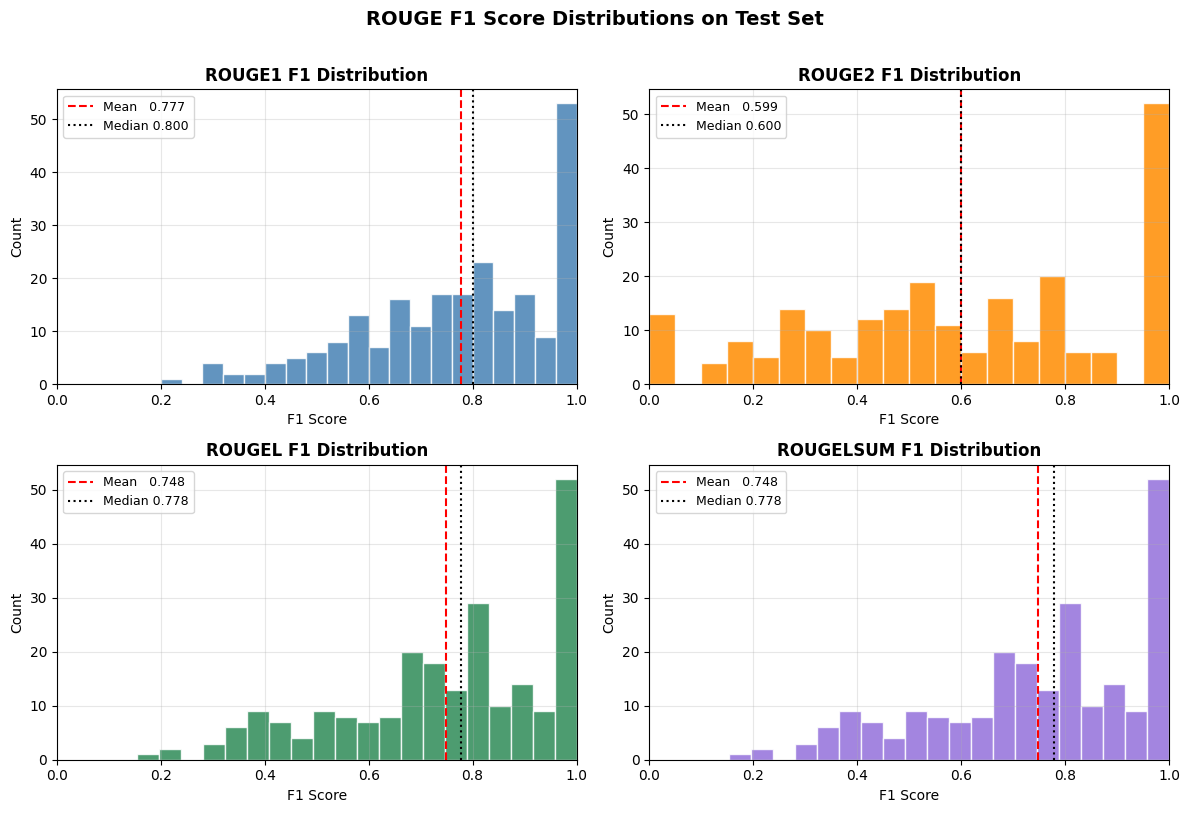


[Step 5] Histogram saved to: /content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1/rouge_evaluation/rouge_distributions.png


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes   = axes.flatten()
colors = ["steelblue", "darkorange", "seagreen", "mediumpurple"]

print("[Step 5] ROUGE F1 Distribution Summary")
print("=" * 60)

for i, metric in enumerate(ROUGE_METRICS):
    col    = f"{metric}_f1"
    values = rouge_df[col]
    ax     = axes[i]

    ax.hist(values, bins=20, color=colors[i], edgecolor="white", alpha=0.85)
    ax.axvline(values.mean(),   color="red",   linestyle="--", linewidth=1.5,
               label=f"Mean   {values.mean():.3f}")
    ax.axvline(values.median(), color="black", linestyle=":",  linewidth=1.5,
               label=f"Median {values.median():.3f}")
    ax.set_title(f"{metric.upper()} F1 Distribution", fontsize=12, fontweight="bold")
    ax.set_xlabel("F1 Score")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    pct_above_08 = (values >= 0.8).mean() * 100
    pct_below_05 = (values <  0.5).mean() * 100
    print(f"  {metric.upper():<12}  mean={values.mean():.4f}  median={values.median():.4f}  "
          f">=0.80: {pct_above_08:.1f}%  <0.50: {pct_below_05:.1f}%")

plt.suptitle("ROUGE F1 Score Distributions on Test Set",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()

dist_path = os.path.join(rouge_dir, "rouge_distributions.png")
plt.savefig(dist_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n[Step 5] Histogram saved to: {dist_path}")

### Step 6 — ROUGE Scores by Action Type (Bar Chart)

[Step 6] ROUGE Mean F1 per Action Type
  ROUGE1        board=0.597  continue=0.793  exit=0.789  stop=0.647  turn=0.968
  ROUGE2        board=0.329  continue=0.623  exit=0.605  stop=0.350  turn=0.947
  ROUGEL        board=0.567  continue=0.782  exit=0.727  stop=0.604  turn=0.963
  ROUGELSUM     board=0.567  continue=0.782  exit=0.727  stop=0.604  turn=0.963


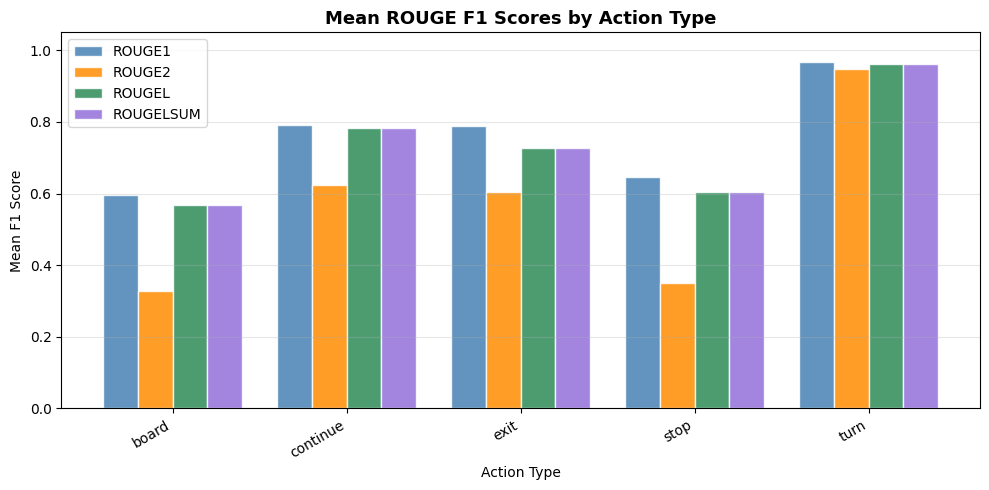


[Step 6] Bar chart saved to: /content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1/rouge_evaluation/rouge_by_action_type.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np

action_types = by_action_rouge["action_type"].tolist()
x          = np.arange(len(action_types))
bar_width   = 0.2
colors      = ["steelblue", "darkorange", "seagreen", "mediumpurple"]

fig, ax = plt.subplots(figsize=(max(10, len(action_types) * 1.8), 5))

print("[Step 6] ROUGE Mean F1 per Action Type")
print("=" * 60)

for i, metric in enumerate(ROUGE_METRICS):
    col    = f"{metric}_f1"
    offset = (i - len(ROUGE_METRICS) / 2 + 0.5) * bar_width
    ax.bar(x + offset, by_action_rouge[col], width=bar_width,
           label=metric.upper(), color=colors[i], alpha=0.85, edgecolor="white")

    scores_str = "  ".join(
        f"{act}={val:.3f}"
        for act, val in zip(action_types, by_action_rouge[col])
    )
    print(f"  {metric.upper():<12}  {scores_str}")

ax.set_xticks(x)
ax.set_xticklabels(action_types, rotation=30, ha="right")
ax.set_xlabel("Action Type")
ax.set_ylabel("Mean F1 Score")
ax.set_title("Mean ROUGE F1 Scores by Action Type", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
bar_path = os.path.join(rouge_dir, "rouge_by_action_type.png")
plt.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n[Step 6] Bar chart saved to: {bar_path}")

### Step 7 — Low-Scoring Examples (ROUGE-L F1 < 0.5)

In [19]:
THRESHOLD = 0.5

low_rouge = (
    rouge_df[rouge_df["rougeL_f1"] < THRESHOLD]
    .sort_values("rougeL_f1")
    [["input", "target", "predicted",
      "rouge1_f1", "rouge2_f1", "rougeL_f1", "rougeLsum_f1"]]
    .reset_index(drop=True)
)

total   = len(rouge_df)
n_low   = len(low_rouge)
pct_low = n_low / total * 100

print(f"[Step 7] Low-Scoring Examples — ROUGE-L F1 < {THRESHOLD}")
print("=" * 80)
print(f"[Step 7] {n_low} / {total} examples below threshold ({pct_low:.1f}%)")
print(f"[Step 7] {total - n_low} / {total} examples at or above threshold "
      f"({100 - pct_low:.1f}%)")
print()

if low_rouge.empty:
    print("[Step 7] No low-scoring examples — all predictions scored ROUGE-L F1 >= 0.50.")
else:
    for idx, row in low_rouge.iterrows():
        print(f"  [{idx + 1}/{n_low}] Input:     {row['input']}")
        print(f"          Target:    {row['target']}")
        print(f"          Predicted: {row['predicted']}")
        print(f"          ROUGE-1={row['rouge1_f1']:.4f}  "
              f"ROUGE-2={row['rouge2_f1']:.4f}  "
              f"ROUGE-L={row['rougeL_f1']:.4f}  "
              f"ROUGE-Lsum={row['rougeLsum_f1']:.4f}")
        print("-" * 80)

[Step 7] Low-Scoring Examples — ROUGE-L F1 < 0.5
[Step 7] 32 / 229 examples below threshold (14.0%)
[Step 7] 197 / 229 examples at or above threshold (86.0%)

  [1/32] Input:     action: board direction: down landmark: stairs
          Target:    Walk down one flight of stairs.
          Predicted: Step onto the stairs to go down.
          ROUGE-1=0.3077  ROUGE-2=0.0000  ROUGE-L=0.1538  ROUGE-Lsum=0.1538
--------------------------------------------------------------------------------
  [2/32] Input:     action: stop
          Target:    Stand still here.
          Predicted: You have reached your destination. Stop here.
          ROUGE-1=0.2000  ROUGE-2=0.0000  ROUGE-L=0.2000  ROUGE-Lsum=0.2000
--------------------------------------------------------------------------------
  [3/32] Input:     action: turn direction: left
          Target:    Make a left turn.
          Predicted: In 15 minutes, turn left.
          ROUGE-1=0.4444  ROUGE-2=0.0000  ROUGE-L=0.2222  ROUGE-Lsum=0.2222
---

### Step 8 — Cross-Validation with HuggingFace `evaluate` Library

In [20]:
import evaluate

hf_rouge = evaluate.load("rouge")

predictions = rouge_df["predicted"].tolist()
references  = rouge_df["target"].tolist()

hf_results = hf_rouge.compute(
    predictions=predictions,
    references=references,
    use_stemmer=True,
    use_aggregator=True,
)

print("[Step 8] HuggingFace evaluate — Corpus-Level ROUGE (mean F1)")
print("=" * 55)
for key, value in sorted(hf_results.items()):
    print(f"  {key:<15} {value:.4f}")

print("\n[Step 8] Cross-library sanity check (rouge_score vs hf evaluate):")
print("-" * 60)
for metric in ROUGE_METRICS:
    rs_val = rouge_df[f"{metric}_f1"].mean()
    hf_val = hf_results.get(metric, float("nan"))
    delta  = abs(rs_val - hf_val)
    status = "OK" if delta < 0.005 else "CHECK"
    print(f"  [{status}] {metric:<12}  rouge_score={rs_val:.4f}  "
          f"hf_evaluate={hf_val:.4f}  delta={delta:.4f}")

print(f"\n[Step 8] Evaluated on {len(predictions)} predictions.")

[Step 8] HuggingFace evaluate — Corpus-Level ROUGE (mean F1)
  rouge1          0.7774
  rouge2          0.5978
  rougeL          0.7483
  rougeLsum       0.7485

[Step 8] Cross-library sanity check (rouge_score vs hf evaluate):
------------------------------------------------------------
  [OK] rouge1        rouge_score=0.7773  hf_evaluate=0.7774  delta=0.0001
  [OK] rouge2        rouge_score=0.5993  hf_evaluate=0.5978  delta=0.0015
  [OK] rougeL        rouge_score=0.7483  hf_evaluate=0.7483  delta=0.0000
  [OK] rougeLsum     rouge_score=0.7483  hf_evaluate=0.7485  delta=0.0002

[Step 8] Evaluated on 229 predictions.


### Step 9 — Save All ROUGE Results to `rouge_evaluation/` Folder

In [21]:
import json

# --- 1. Per-sample scores CSV ---
csv_path = os.path.join(rouge_dir, "rouge_per_sample.csv")
rouge_df.to_csv(csv_path, index=False)
print(f"[Step 9] Per-sample ROUGE scores   → {csv_path}")
print(f"         Rows: {len(rouge_df)}  |  Columns: {list(rouge_df.columns)}")

# --- 2. Per-action-type breakdown CSV ---
action_csv_path = os.path.join(rouge_dir, "rouge_by_action_type.csv")
by_action_rouge.to_csv(action_csv_path, index=False)
print(f"\n[Step 9] Per-action-type breakdown → {action_csv_path}")
print(f"         Action types: {by_action_rouge['action_type'].tolist()}")

# --- 3. Aggregate summary JSON ---
aggregate_summary = {"n_samples": len(rouge_df), "metrics": {}}
for metric in ROUGE_METRICS:
    col = f"{metric}_f1"
    aggregate_summary["metrics"][metric] = {
        "mean_f1":   round(rouge_df[col].mean(),   4),
        "median_f1": round(rouge_df[col].median(), 4),
        "std_f1":    round(rouge_df[col].std(),    4),
        "min_f1":    round(rouge_df[col].min(),    4),
        "max_f1":    round(rouge_df[col].max(),    4),
    }
aggregate_summary["hf_evaluate_corpus_f1"] = {
    k: round(v, 4) for k, v in hf_results.items()
}
aggregate_summary["low_scoring_examples"] = {
    "threshold_rougeL_f1": THRESHOLD,
    "count":      int(n_low),
    "percentage": round(pct_low, 2),
}

json_path = os.path.join(rouge_dir, "rouge_summary.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(aggregate_summary, f, indent=2)
print(f"\n[Step 9] Aggregate summary JSON    → {json_path}")

# --- Final checklist ---
print("\n" + "=" * 65)
print("[Step 9] ROUGE EVALUATION COMPLETE — FILE CHECKLIST")
print("=" * 65)
saved_files = [
    ("rouge_per_sample.csv",       "Per-sample P / R / F1 for all ROUGE variants"),
    ("rouge_by_action_type.csv",   "Mean F1 per action type"),
    ("rouge_summary.json",         "Aggregate stats + HF cross-check + low-score summary"),
    ("rouge_distributions.png",    "F1 histogram (2x2 grid, all variants)"),
    ("rouge_by_action_type.png",   "Grouped bar chart by action type"),
]
for fname, desc in saved_files:
    fpath  = os.path.join(rouge_dir, fname)
    status = "OK" if os.path.exists(fpath) else "MISSING"
    print(f"  [{status}] {fname:<35} {desc}")

print(f"\n[Step 9] Output folder: {rouge_dir}")
print("\n[Step 9] Aggregate summary:")
print(json.dumps(aggregate_summary, indent=2))

[Step 9] Per-sample ROUGE scores   → /content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1/rouge_evaluation/rouge_per_sample.csv
         Rows: 229  |  Columns: ['input', 'target', 'predicted', 'rouge1_precision', 'rouge1_recall', 'rouge1_f1', 'rouge2_precision', 'rouge2_recall', 'rouge2_f1', 'rougeL_precision', 'rougeL_recall', 'rougeL_f1', 'rougeLsum_precision', 'rougeLsum_recall', 'rougeLsum_f1', 'action_type']

[Step 9] Per-action-type breakdown → /content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1/rouge_evaluation/rouge_by_action_type.csv
         Action types: ['board', 'continue', 'exit', 'stop', 'turn']

[Step 9] Aggregate summary JSON    → /content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1/rouge_evaluation/rouge_summary.json

[Step 9] ROUGE EVALUATION COMPLETE — FILE CHECKLIST
  [OK] rouge